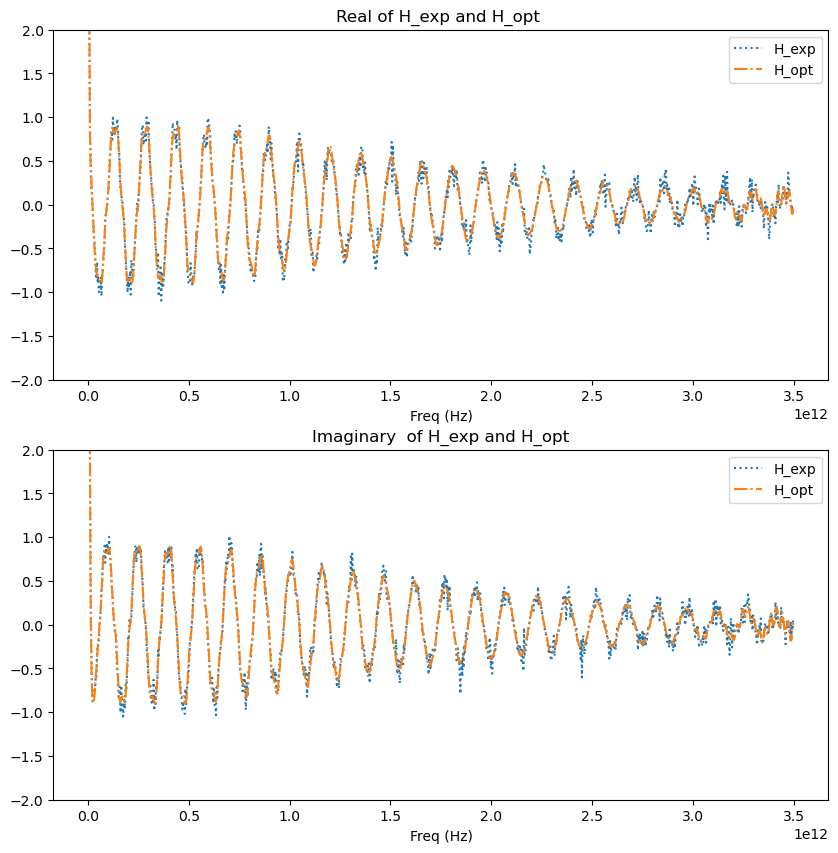

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#load data 
n_0=np.loadtxt("n_0.txt")
n_=n_0[:,1]
k_=n_0[:,2]
n=n_+1j*k_
freq=n_0[:,0]

#constants
L=2e-3 #thickness of sample
c=3e8 #speed of light
num_samples=5000 #number of iterations

#calculate theoretical transfer function
H_th=(4 * n) / ((1 + n) ** 2) * np.exp(-1j * L * 2 * np.pi * freq * (n - 1) / c)

#add noise to the theoretical transfer function
H_exp=(np.abs(H_th)+np.random.normal(0,0.1,len(H_th)))*np.exp(1j*(np.angle(H_th)+np.random.normal(0,0.05,len(H_th))))


def H_proposed(n_p):
    return (4 * n_p) / ((1 + n_p) ** 2) * np.exp(-1j * L * 2 * np.pi * freq * (n_p - 1) / c)
    
def Loss_function(n_p):
    return np.sum(np.abs((H_proposed(n_p) - H_exp)) ** 2)

samples = []
n_now = n #initial guess

for _ in range(num_samples):
    
    n_new = n_now + np.random.normal(0, 0.05, len(n_)) + 1j * np.random.normal(0, 0.01, len(n_))
    acceptance_ratio = np.exp(Loss_function(n_now)-Loss_function(n_new))  
    if np.random.rand() < acceptance_ratio:
        n_now = n_new 

    samples.append(n_now)

samples = np.array(samples)

n_opt = samples[-1]
H_opt = (4 * n_opt) / ((1 + n_opt) ** 2) * np.exp(-1j * L * 2 * np.pi * freq * (n_opt - 1) / c)


plt.figure(figsize=(10, 10))

plt.subplot(2, 1, 1)
plt.plot(freq, np.real(H_exp), label="H_exp", linestyle=':')
plt.plot(freq, np.real(H_opt), label="H_opt", linestyle='-.')
plt.legend()
plt.xlabel("Freq (Hz)")
plt.title("Real of H_exp and H_opt ")
plt.ylim(-2,2)

plt.subplot(2, 1, 2)
plt.plot(freq, np.imag(H_exp), label="H_exp", linestyle=':')
plt.plot(freq, np.imag(H_opt), label="H_opt", linestyle='-.')
plt.legend()
plt.xlabel("Freq (Hz)")
plt.title("Imaginary  of H_exp and H_opt")
plt.ylim(-2,2)

plt.show()
